In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import statsmodels.api as sm
from statsmodels.api import OLS, Logit
from sklearn.metrics import *

# Generación de números aleatorios

In [51]:
# sin semilla

for _ in range(5):
    print(round(np.random.rand(), 6))

0.633648
0.748804
0.498507
0.224797
0.198063


In [52]:
# con semilla

for _ in range(5):
    np.random.seed(10)
    print(round(np.random.rand(), 6))

0.771321
0.771321
0.771321
0.771321
0.771321


# Train test split

In [91]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X_raw = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_raw = diabetes.target

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

In [95]:
# STATSMODEL

X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit()

y_pred_train = model_ols.predict(X_train_sm)
y_pred_test  = model_ols.predict(X_test_sm)

print(f"RMSE  Train: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"RMSE  Test:  {np.sqrt(mean_squared_error(y_test,  y_pred_test)):.2f}")
print(f"R²    Train: {r2_score(y_train, y_pred_train):.4f}")
print(f"R²    Test:  {r2_score(y_test,  y_pred_test):.4f}")

RMSE  Train: 53.56
RMSE  Test:  53.85
R²    Train: 0.5279
R²    Test:  0.4526


In [96]:
# SKLEARN / CV
from sklearn.model_selection import train_test_split, KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Con sklearn
lr = LinearRegression()
cv_r2 = cross_val_score(lr, X_raw, y_raw, cv=kf, scoring="r2")
cv_r2

array([0.45260276, 0.57320015, 0.39144785, 0.58428888, 0.39081186])

# Problema de regresión

In [78]:
seed = 99

df = pd.read_csv('https://raw.githubusercontent.com/eduardofc/data/main/boston.csv')
X = df.drop(columns=['target']) # , 'INDUS', 'AGE', 'TAX', 'NOX', 'RAD' <-- lo que quitábamos en lo explicativo
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

In [79]:
# Regresión lineal

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model_sm = OLS(y_train, X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     99.69
Date:                Tue, 19 May 2026   Prob (F-statistic):          6.94e-111
Time:                        13:12:27   Log-Likelihood:                -1180.4
No. Observations:                 404   AIC:                             2387.
Df Residuals:                     391   BIC:                             2439.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.6442      5.252      7.358      0.000      28.318      48.970
CRIM          -0.1323      0.033     -4.019      0.000      -0.197      -0.068
ZN             0.0484      0.015      3.220      0.001       0.019       0.078
INDUS          0.0129      0.068      0.191      0.849      -0.120       0.146
CHAS           2.1171      0.997      2.124      0.034       0.158       4.077
NOX          -14.8592      4.045     -3.673      0.000     -22.813      -6.906
RM             3.7843      0.448      8.442      0.000       2.903       4.666
AGE            0.0016      0.014      0.113      0.910      -0.026       0.030
DIS           -1.4745      0.212     -6.956      0.000      -1.891      -1.058
RAD            0.2521      0.070      3.618      0.000       0.115       0.389
TAX           -0.0120      0.004     -2.986      0.003      -0.020      -0.004
PTRATIO       -0.9044      0.140     -6.461      0.000      -1.180      -0.629
LSTAT         -0.5917      0.055    -10.683      0.000      -0.701      -0.483
==============================================================================
Omnibus:                      110.119   Durbin-Watson:                   1.940
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              374.962
Skew:                           1.206   Prob(JB):                     3.78e-82
Kurtosis:                       7.056   Cond. No.                     1.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [80]:
y_hat_train_sm = model_sm.predict(X_train_sm)
y_hat_test_sm = model_sm.predict(X_test_sm)

print(f"MAE Train: {mean_absolute_error(y_train, y_hat_train_sm):.2f}")
print(f"MAE Test : {mean_absolute_error(y_test,  y_hat_test_sm):.2f}")
print(f"R2  Train: {r2_score(y_train, y_hat_train_sm):.4f}")
print(f"R2  Test : {r2_score(y_test,  y_hat_test_sm):.4f}")

MAE Train: 3.23
MAE Test : 3.77
R2  Train: 0.7537
R2  Test : 0.6540


In [81]:
from sklearn.linear_model import LinearRegression

model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

LinearRegression()

In [82]:
y_hat_train_sk = model_sk.predict(X_train)
y_hat_test_sk = model_sk.predict(X_test)

print(f"MAE Train: {mean_absolute_error(y_train, y_hat_train_sk):.2f}")
print(f"MAE Test : {mean_absolute_error(y_test,  y_hat_test_sk):.2f}")
print(f"R2  Train: {r2_score(y_train, y_hat_train_sk):.4f}")
print(f"R2  Test : {r2_score(y_test,  y_hat_test_sk):.4f}")

MAE Train: 3.23
MAE Test : 3.77
R2  Train: 0.7537
R2  Test : 0.6540


## Regularización

### Sklearn

In [90]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge (L2)": RidgeCV(alpha=1.0),
#     "Lasso (L1)": LassoCV(alpha=0.05),
#     "ElasticNet (L1+L2)": ElasticNetCV(alpha=0.05, l1_ratio=0.5)
# }
alphas_a_probar = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": RidgeCV(alphas=alphas_a_probar),
    "Lasso (L1)": LassoCV(cv=5, random_state=42),
    "ElasticNet (L1+L2)": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_hat_train = model.predict(X_train_scaled)
    y_hat_test = model.predict(X_test_scaled)

    print(f"{name}: {r2_score(y_train, y_hat_train):.4f} vs {r2_score(y_test, y_hat_test):.4f}")

Linear Regression: 0.7537 vs 0.6540
Ridge (L2): 0.7525 vs 0.6529
Lasso (L1): 0.7535 vs 0.6525
ElasticNet (L1+L2): 0.7533 vs 0.6529


In [7]:
# Explicar aquí el train-test split con más ejemplos

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, random_state=33
)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit()

y_hat_train = model_ols.predict(X_train_sm)
y_hat_test  = model_ols.predict(X_test_sm)

print(f"MAE Train: {mean_absolute_error(y_train, y_hat_train):.2f}")
print(f"MAE Test : {mean_absolute_error(y_test,  y_hat_test):.2f}")
print(f"R2  Train: {r2_score(y_train, y_hat_train):.4f}")
print(f"R2  Test : {r2_score(y_test,  y_hat_test):.4f}")

MAE Train: 3.34
MAE Test : 3.64
R2  Train: 0.7413
R2  Test : 0.6773


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=33
)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model_ols = sm.Logit(y_train, X_train).fit()

y_hat_train_probs = model_ols.predict(X_train)
y_hat_test_probs = model_ols.predict(X_test)

# umbral 0.5
y_hat_train = (y_hat_train_probs >= 0.5).astype(int)
y_hat_test = (y_hat_test_probs >= 0.5).astype(int)

print(f"Accuracy Train: {accuracy_score(y_train, y_hat_train):.4f}")
print(f"Accuracy Test : {accuracy_score(y_test, y_hat_test):.4f}")

Optimization terminated successfully.
         Current function value: 0.155666
         Iterations 10
Accuracy Train: 0.9451
Accuracy Test : 0.8860


# Sklearn

In [10]:
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, random_state=33
)

model3 = LinearRegression()
model3.fit(X_train, y_train)

y_hat_train = model3.predict(X_train)
y_hat_test = model3.predict(X_test)

print(f"MAE Train: {mean_absolute_error(y_train, y_hat_train):.2f}")
print(f"MAE Test : {mean_absolute_error(y_test,  y_hat_test):.2f}")
print(f"R2  Train: {r2_score(y_train, y_hat_train):.4f}")
print(f"R2  Test : {r2_score(y_test,  y_hat_test):.4f}")

MAE Train: 3.34
MAE Test : 3.64
R2  Train: 0.7413
R2  Test : 0.6773


In [12]:
# a partir de aquí continuamos solo con la regresión lineal

# Cross Validation

# Regularization

In [13]:
# Exploramos las documentación de sklearn

In [38]:
df = pd.read_csv('https://raw.githubusercontent.com/eduardofc/data/main/boston.csv')
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33
)

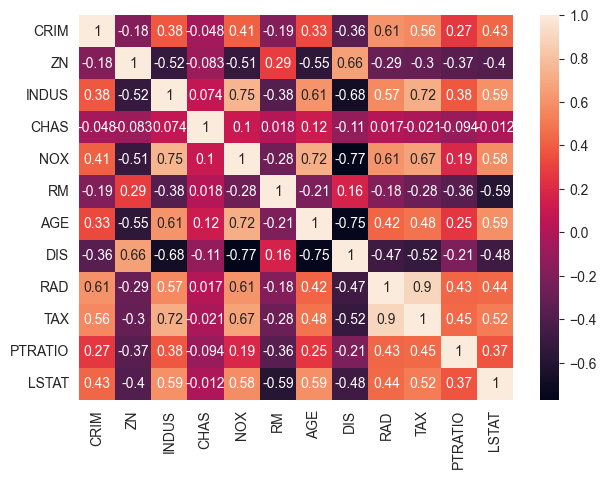

In [39]:
plt.figure(figsize=(7,5))
sns.heatmap(X_train.corr(numeric_only=True), annot=True)
plt.show()

In [42]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for ii, col in enumerate(X_train_sm.columns):
    vif = variance_inflation_factor(X_train_sm.values, ii)
    print(f"{col}: {vif:.2f}")

const: 538.29
CRIM: 1.70
ZN: 2.22
INDUS: 3.86
CHAS: 1.07
NOX: 4.42
RM: 1.86
AGE: 3.06
DIS: 4.06
RAD: 6.91
TAX: 8.64
PTRATIO: 1.74
LSTAT: 2.71


In [30]:
X_sm = sm.add_constant(X)

model1 = OLS(y, X_sm).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Tue, 19 May 2026   Prob (F-statistic):          2.23e-133
Time:                        12:45:25   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.6173      4.936      8.431      0.000      31.919      51.316
CRIM          -0.1214      0.033     -3.678      0.000      -0.186      -0.057
ZN             0.0470      0.014      3.384      0.001       0.020       0.074
INDUS          0.0135      0.062      0.217      0.829      -0.109       0.136
CHAS           2.8400      0.870      3.264      0.001       1.131       4.549
NOX          -18.7580      3.851     -4.870      0.000     -26.325     -11.191
RM             3.6581      0.420      8.705      0.000       2.832       4.484
AGE            0.0036      0.013      0.271      0.787      -0.023       0.030
DIS           -1.4908      0.202     -7.394      0.000      -1.887      -1.095
RAD            0.2894      0.067      4.325      0.000       0.158       0.421
TAX           -0.0127      0.004     -3.337      0.001      -0.020      -0.005
PTRATIO       -0.9375      0.132     -7.091      0.000      -1.197      -0.678
LSTAT         -0.5520      0.051    -10.897      0.000      -0.652      -0.452
==============================================================================
Omnibus:                      171.096   Durbin-Watson:                   1.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.937
Skew:                           1.477   Prob(JB):                    6.90e-155
Kurtosis:                       7.995   Cond. No.                     1.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Modelo Explicativo

In [19]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.05), # Usamos un alpha bajo porque L1 es muy agresivo
    "ElasticNet (L1+L2)": ElasticNet(alpha=0.05, l1_ratio=0.5)
}

# 6. Entrenar y evaluar
print("--- Resultados de Predicción (Umbral de 0.5) ---")
for name, model in models.items():
    # Entrenar modelo
    model.fit(X_train_scaled, y_train)

    # Predecir (esto devolverá números continuos, ej: 0.83, 0.12, -0.05)
    y_pred_cont = model.predict(X_test_scaled)

    # Convertir a clases usando un umbral de 0.5
    y_pred_class = (y_pred_cont >= 0.5).astype(int)

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred_class)
    mse = mean_squared_error(y_test, y_pred_cont)

    print(f"🔸 {name}:")
    print(f"   Accuracy (Clasificación): {acc*100:.2f}%")
    print(f"   Error Cuadrático Medio (MSE): {mse:.4f}\n")

# Extra: Ver el poder de Lasso (Selección de características)
lasso_model = models["Lasso (L1)"]
coeficientes_cero = sum(lasso_model.coef_ == 0)
print(f"💡 Lasso ha reducido {coeficientes_cero} de las {X.shape[1]} variables a exactamente 0.")

--- Resultados de Predicción (Umbral de 0.5) ---
🔸 Linear Regression:
   Accuracy (Clasificación): 95.61%
   Error Cuadrático Medio (MSE): 0.0641

🔸 Ridge (L2):
   Accuracy (Clasificación): 95.61%
   Error Cuadrático Medio (MSE): 0.0621

🔸 Lasso (L1):
   Accuracy (Clasificación): 94.74%
   Error Cuadrático Medio (MSE): 0.0650

🔸 ElasticNet (L1+L2):
   Accuracy (Clasificación): 95.61%
   Error Cuadrático Medio (MSE): 0.0631

💡 Lasso ha reducido 25 de las 30 variables a exactamente 0.


# Problema de clasificación

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/breast_cancer_data.csv")
df = df[['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean', 'diagnosis']]
X = df.drop(columns=['diagnosis', 'symmetry_mean'])
y = df['diagnosis'].map({'M': 1, 'B': 0})

In [6]:
# regresión logística

X2 = df2.drop(columns=['diagnosis', 'symmetry_mean'])
X2_sm = sm.add_constant(X2)
y2 = df2["diagnosis"].map({'M': 1, 'B': 0})

model = sm.Logit(y2, X2_sm)
results = model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.139603
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      563
Method:                           MLE   Df Model:                            5
Date:                Tue, 19 May 2026   Pseudo R-squ.:                  0.7886
Time:                        12:25:10   Log-Likelihood:                -79.434
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                8.144e-126
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -32.7312      5.798     -5.645      0.000     -44.095     -21.368
radius_mean                1.1225      0.179      6.265      0.000       0.771       1.474
texture_mean               0.3734      0.061      6.093      0.000       0.253       0.494
smoothness_mean          132.2116     24.297      5.441      0.000      84.590     179.833
concavity_mean            27.1612      5.695      4.769      0.000      15.999      38.323
fractal_dimension_mean  -100.3746     59.398     -1.690      0.091    -216.793      16.044
==========================================================================================

Possibly complete quasi-separation: A fraction 0.17 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [11]:
# Sklearn
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=33
)

model4 = LogisticRegression()
model4.fit(X_train, y_train)

y_hat_train = model4.predict(X_train)
y_hat_test = model4.predict(X_test)

print(f"Accuracy Train: {accuracy_score(y_train, y_hat_train):.4f}")
print(f"Accuracy Test : {accuracy_score(y_test, y_hat_test):.4f}")

Accuracy Train: 0.9011
Accuracy Test : 0.8772
